# Recipe for identifying and tracking the Masato et al. (2012) blocking index from 500hPa geopotential using wxlib

#### This recipe is relatively untested. The results should be used with caution and scrutinised before being used in any formal analysis 

Written by:

Michael Barnes (ARC CoE for 21st Century Weather) | michael.barnes@monash.edu 

Tess Parker (CSIRO) | tess.parker@csiro.au

Publication to cite: 

Masato, G., Hoskins, B. J. and Woollings T. J. (2012). Wave-breaking characteristics of midlatitude blocking. QJRMS. https://doi.org/10.1002/qj.990

In [1]:
import sys
import os
import numpy as np
import xarray as xr
import pandas as pd
import pickle
import cartopy.crs as ccrs
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta

Point path to wxlib and import relavent modules

In [2]:
sys.path.append('/g/data/gb02/mb0427/wxlib/functions/')
from detect_blocks import detect_blocks_by_masato
from plotting import plot_tracks_at_time
from utility import generate_datetimes_months
from tracking import update_init_track_lens
from nci_utilities import get_GADI_ERA5_filename

Set the output path and list of monthly datetimes for which you want calculations done

In [3]:
running_time=0 #in timesteps
overlap_perc=25
outpath='/g/data/gb02/mb0427/blocking/masato/mean'+str(int(running_time*6))+'/overlap'+str(int(overlap_perc))+'/'
dtlist=generate_datetimes_months(datetime(2022,3,1),datetime(2022,3,1))
first_mn=dtlist[0]

Load the ERA5 z500 data and run the detection algorithm

In [4]:
for imn,mn in enumerate(dtlist):
    print(mn.strftime('%Y%m'))
    fn=get_GADI_ERA5_filename('z',mn,stream='hourly',level_type='pressure-levels')
    z500=xr.open_dataset(fn).sel(level=500).resample(time='6h').nearest().z
    
    if running_time>0:
        print('Calculating running mean ...')
        mndm1=mn-relativedelta(months=1)
        z_dm1=xr.open_dataset(get_GADI_ERA5_filename('z',mndm1,stream='hourly',level_type='pressure-levels')).resample(time='6h').nearest().z
        z_dm1=z_dm1.sel(time=slice(mn-relativedelta(days=10),mn-relativedelta(hours=1)))
        mndp1=mn+relativedelta(months=1)
        z_dp1=xr.open_dataset(get_GADI_ERA5_filename('z',mndp1,stream='hourly',level_type='pressure-levels')).resample(time='6h').nearest().z
        z_dp1=z_dp1.sel(time=slice(mndp1,mndp1+relativedelta(days=10)))
        
        z500=xr.concat([z_dm1,z500,z_dp1],dim='time')
        z500=z500.rolling(time=running_time, center=True).mean()
        z500=z500.sel(time=slice(mn,mndp1-relativedelta(hours=1)))

        del z_dm1,z_dp1
    
    if mn==first_mn:
        init_obj_arr=None
        init_df=None
    else:
        init_mn=mn-relativedelta(months=1)
        init_fn='test_masato_mean'+str(int(running_time*6))+'_overlap'+str(int(overlap_perc))+'_'+init_mn.strftime('%Y%m')
        init_obj_arr=xr.open_dataset(outpath+init_fn+'.nc').highs
        init_df=pd.read_pickle(outpath+init_fn+'.pkl')

    high_obj_xr,high_df,grid,b_index=\
                detect_blocks_by_masato(z500,
                    init_df=init_df,init_obj_arr=init_obj_arr,
                    min_overlap_perc=overlap_perc,dT=6,
                    min_area=None,min_living_tstep=None,
                    return_data=True,quiet=False,outpath=outpath,
                    outfilename='test_masato_mean'+str(int(running_time*6))+'_overlap'+str(int(overlap_perc))+'_'+mn.strftime('%Y%m'))
    
    if mn!=first_mn:
        with open(outpath+init_fn+'_updated.pkl', 'wb') as handle:
            pickle.dump(update_init_track_lens(init_df,high_df), handle)

202203
Detecting blocks ...
   - Calculate masato blocking index...


Masato blocking index calculation: 100%|██████████| 124/124 [03:03<00:00,  1.48s/it]


   - Detecting potential blocks (thresh_id)...
        connect objects over date line
   - Producing the object characteristics ...
            Loop over 725 objects
   - Tracking by overlap ...


/g/data/gb02/mb0427/wxlib/functions/tracking.py:117: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  processed_df = indf.groupby("track_id").apply(lambda group: process_group(group.copy(), incoord))


Completed!
        00:04:06.30


In [5]:
xr_to_plot=high_obj_xr*1#xr.concat([init_obj_arr,high_obj_xr],dim='time')
df_to_plot=high_df.copy()#pd.concat((init_df,high_df))

Plot the tracks

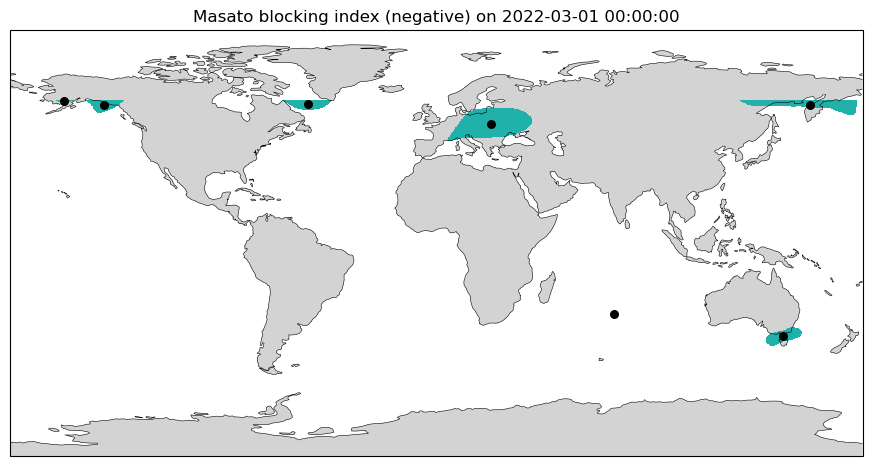

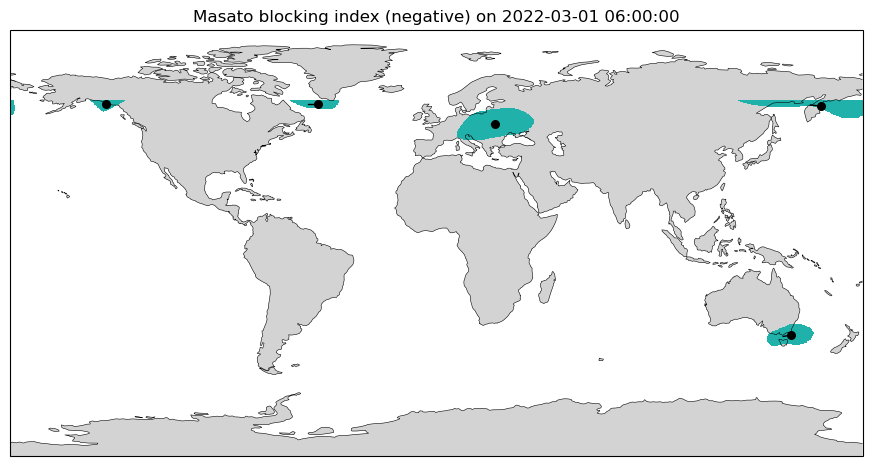

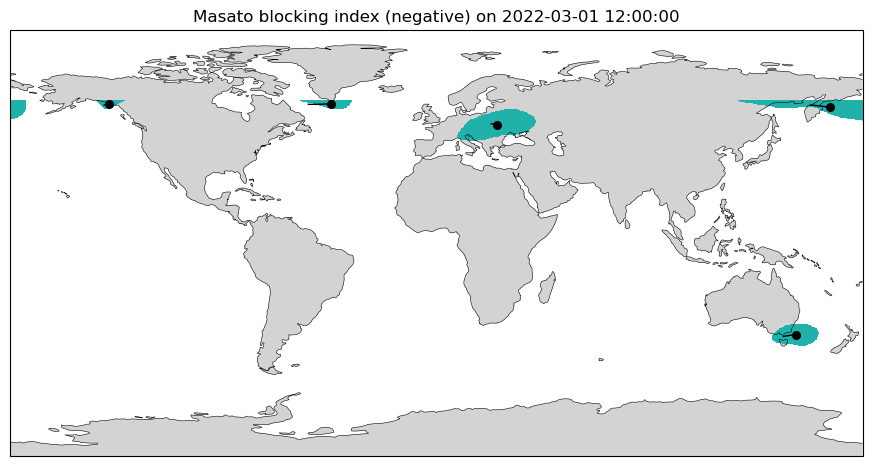

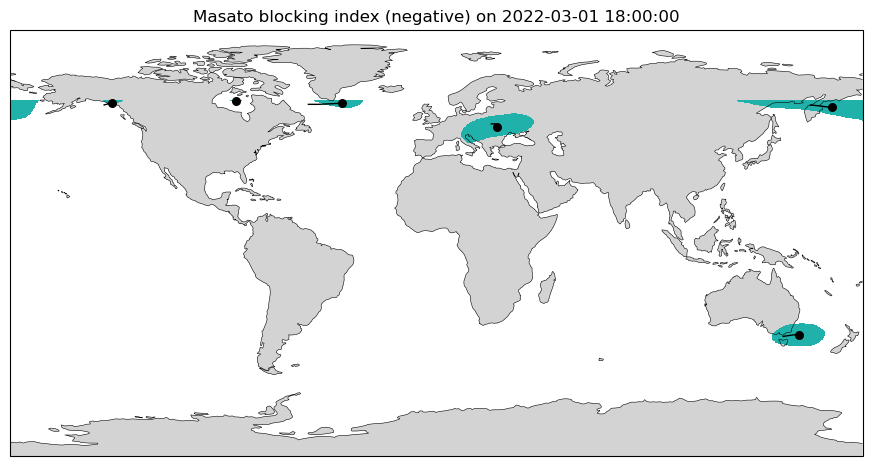

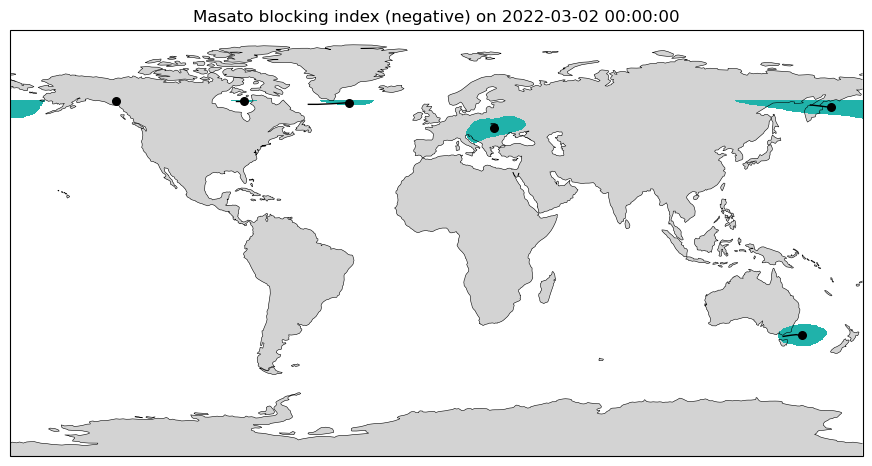

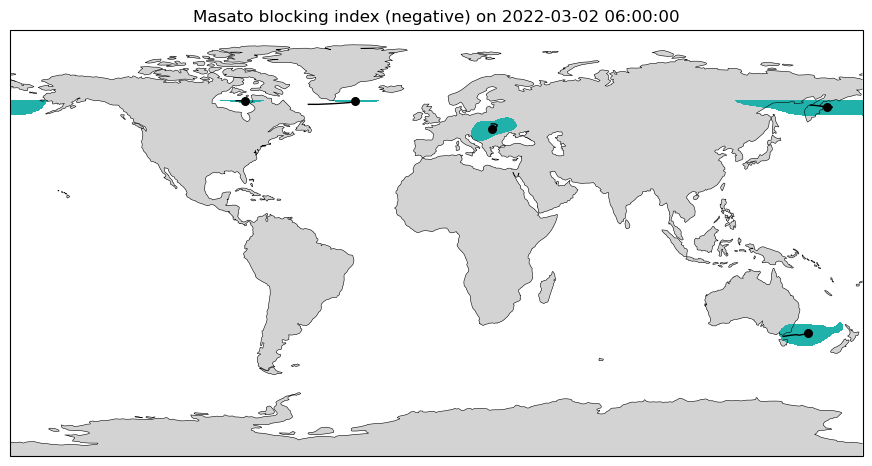

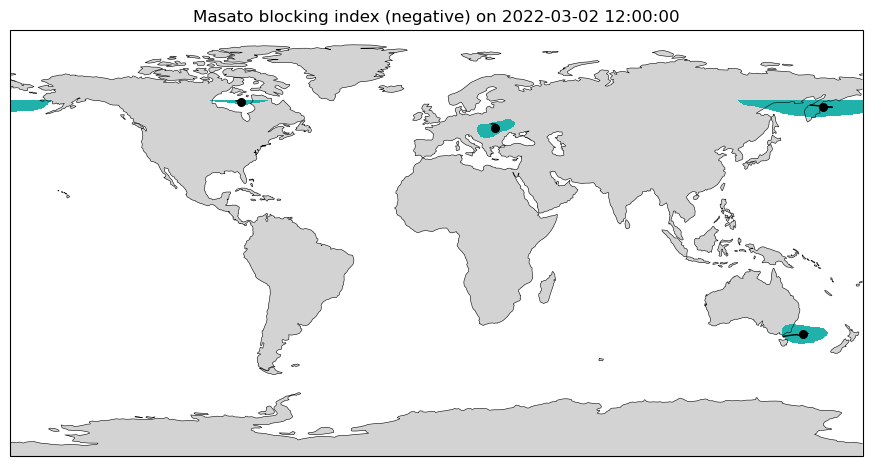

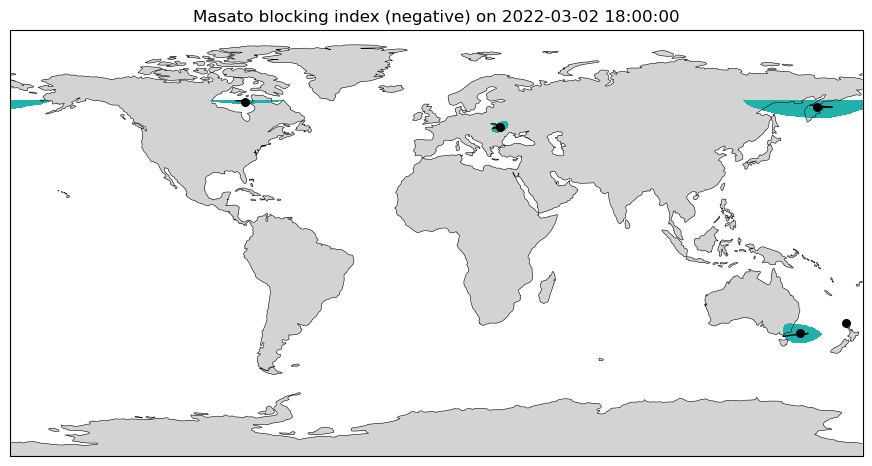


KeyboardInterrupt



In [6]:
for idt,dt in enumerate(grid['time'][0:11]):
    plot_tracks_at_time(df_to_plot,xr_to_plot,dt,image_desc='Masato blocking index (negative)',
                        outpath=None,outfileprefix=None,projection=ccrs.PlateCarree())